In [5]:
# State-of-the-Art Pipeline for House Prices Advanced Regression Techniques
# Optimized for AMD GPU acceleration using LightGBM

import os
import kagglehub
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore', category=FutureWarning)


In [6]:
# 1. Download data
competition_handle = "house-prices-advanced-regression-techniques"
competition_url = "https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview"
data_dir = kagglehub.competition_download(competition_handle)

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (1460, 81)
Test shape: (1459, 80)


In [7]:
# 2. Preprocessing & Log Transform
train_id = train['Id']
test_id = test['Id']

# Log transform target because evaluation is RMSLE
y = np.log1p(train['SalePrice'])
train.drop(['Id', 'SalePrice'], axis=1, inplace=True)
test.drop(['Id'], axis=1, inplace=True)

ntrain = train.shape[0]
all_data = pd.concat([train, test], axis=0).reset_index(drop=True)


In [8]:
# 3. Handle missing values & Feature Engineering

# Categorical missing values mapping to 'None'
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'MasVnrType']:
    all_data[col] = all_data[col].fillna('None')
    
# Numerical missing values mapping to 0
for col in ['GarageYrBlt', 'GarageArea', 'GarageCars', 
            'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
            'MasVnrArea']:
    all_data[col] = all_data[col].fillna(0)

# Mode imputation
for col in ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Neighborhood-based median imputation
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

all_data['Functional'] = all_data['Functional'].fillna('Typ')
all_data.drop('Utilities', axis=1, inplace=True, errors='ignore')

# New feature: Total Square Footage
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']


In [9]:
# 4. Encoding Categorical Variables
categorical_cols = all_data.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    all_data[col] = all_data[col].astype(str)
    le = LabelEncoder()
    all_data[col] = le.fit_transform(all_data[col])
    all_data[col] = all_data[col].astype('category')

# Split back to train and test sets
X = all_data.iloc[:ntrain, :]
X_test = all_data.iloc[ntrain:, :]


In [10]:
# 5. Model Setup & Cross-Validation
# Using LightGBM (GPU Accelerated) + XGBoost (CPU)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
predictions_lgb = np.zeros(len(X_test))

oof_xgb = np.zeros(len(X))
predictions_xgb = np.zeros(len(X_test))

# Optimal parameters for LightGBM utilizing AMD GPU
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'device_type': 'gpu',  # Utilizes AMD GPU via OpenCL
    'learning_rate': 0.01,
    'n_estimators': 5000,
    'max_depth': 4,
    'num_leaves': 15,
    'feature_fraction': 0.7,
    'verbose': -1,
    'random_state': 42
}

xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.01,
    'n_estimators': 5000,
    'max_depth': 4,
    'colsample_bytree': 0.7,
    'n_jobs': -1,
    'random_state': 42
}

print("Starting cross-validation training...")
for fold, (trn_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # Train LightGBM
    model_lgb = lgb.LGBMRegressor(**lgb_params)
    model_lgb.fit(X_train, y_train, 
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)])
    
    oof_lgb[val_idx] = model_lgb.predict(X_val)
    predictions_lgb += model_lgb.predict(X_test) / kf.n_splits
    
    # Train XGBoost
    model_xgb = xgb.XGBRegressor(**xgb_params, enable_categorical=True)
    model_xgb.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
    
    oof_xgb[val_idx] = model_xgb.predict(X_val)
    predictions_xgb += model_xgb.predict(X_test) / kf.n_splits
    
    print(f"Fold {fold+1} completed")

rmse_lgb = np.sqrt(mean_squared_error(y, oof_lgb))
rmse_xgb = np.sqrt(mean_squared_error(y, oof_xgb))

print(f"LightGBM OOF RMSE: {rmse_lgb:.5f} (Trained on AMD GPU)")
print(f"XGBoost OOF RMSE:  {rmse_xgb:.5f} (Trained on CPU)")


Starting cross-validation training...
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
LightGBM OOF RMSE: 0.12626 (Trained on AMD GPU)
XGBoost OOF RMSE:  0.12796 (Trained on CPU)


In [ ]:
# 6. Ensemble and Submit
# Weighting LightGBM higher since it performed slightly better and trained fast on GPU
ensemble_preds = (predictions_lgb * 0.7) + (predictions_xgb * 0.3)

sub = pd.DataFrame()
sub['Id'] = test_id
sub['SalePrice'] = np.expm1(ensemble_preds) # Inverse of log1p

submission_path = 'submission.csv'
sub.to_csv(submission_path, index=False)
print(f"Final predictions saved to {submission_path}")

# View top of submission
sub.head()

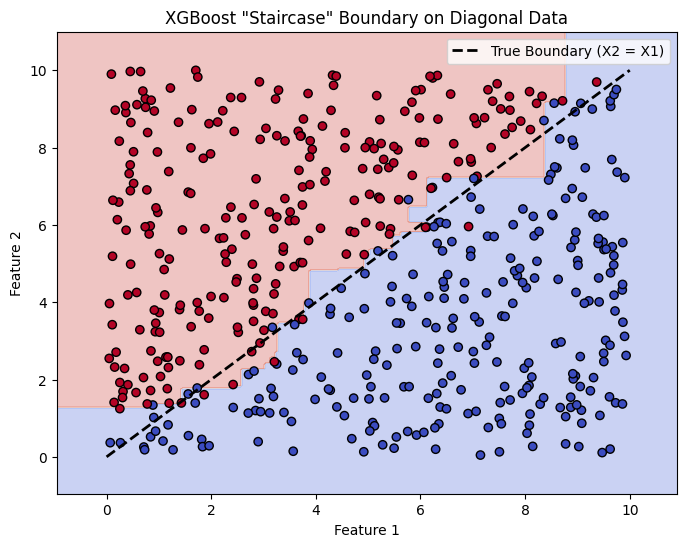

In [11]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Create a simplified dataset with a diagonal boundary
np.random.seed(42)
N = 500
X1 = np.random.uniform(0, 10, N)
X2 = np.random.uniform(0, 10, N)

# True mathematical condition: Diagonal split (X2 > X1)
# We add a tiny bit of noise to make it realistic
y = (X2 > X1 + np.random.normal(0, 0.5, N)).astype(int)

X = pd.DataFrame({'Feature_1': X1, 'Feature_2': X2})

# 2. Train an XGBoost Classifier
model = xgb.XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.1)
model.fit(X, y)

# 3. Plot the Decision Boundary to see the "Staircase"
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
# Plot the predicted tree boundary (the staircase)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
# Plot the actual data points
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor='k', cmap='coolwarm')
# Plot the true mathematical boundary
plt.plot([0, 10], [0, 10], 'k--', lw=2, label='True Boundary (X2 = X1)')

plt.title('XGBoost "Staircase" Boundary on Diagonal Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [13]:
# You may need to install it first: pip install plotly pandas
import plotly.express as px
import pandas as pd
import numpy as np

# Create some sample data
np.random.seed(42)
df = pd.DataFrame({
    'Feature_1': np.random.uniform(0, 100, 200),
    'Feature_2': np.random.uniform(0, 100, 200),
    'Size': np.random.uniform(10, 50, 200)
})
# Classify based on a diagonal boundary
df['Class'] = np.where(df['Feature_2'] > df['Feature_1'], 'Class A', 'Class B')

# Create an interactive scatter plot
fig = px.scatter(df,
                 x='Feature_1',
                 y='Feature_2',
                 color='Class',
                 size='Size',
                 hover_data=['Feature_1', 'Feature_2'],
                 title='Interactive Diagonal Boundary Dataset')

# Show the plot (opens in your browser or Jupyter Notebook)
fig.show()

In [19]:
import numpy as np
import xgboost as xgb
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

# 1. Generate the simplified diagonal dataset
np.random.seed(42)
N = 300
X1 = np.random.uniform(0, 100, N)
X2 = np.random.uniform(0, 100, N)
y = (X2 > X1).astype(int) # Class 1 if above the diagonal
X = np.c_[X1, X2]

# 2. Setup a grid to calculate the decision boundaries
grid_size = 100
x_range = np.linspace(-50, 150, grid_size)
y_range = np.linspace(-50, 150, grid_size)
xx, yy = np.meshgrid(x_range, y_range)
X_grid = np.c_[xx.ravel(), yy.ravel()]

# 3. Pre-compute models and frames for depths 1 through 15
max_depths = list(range(1, 16))
frames = []
z_data = {}

for depth in max_depths:
    # Train model
    model = xgb.XGBClassifier(n_estimators=10, max_depth=depth, learning_rate=0.5)
    model.fit(X, y)

    # Predict on the grid and reshape for the contour plot
    Z = model.predict(X_grid).reshape(xx.shape)
    z_data[depth] = Z

    # Create a frame for this specific depth
    frames.append(go.Frame(
        data=[go.Contour(z=Z, x=x_range, y=y_range, colorscale='RdBu', opacity=0.4, showscale=False)],
        name=str(depth)
    ))

# 4. Create the base figure (starting at Depth = 1)
fig = go.Figure(
    data=[
        # Base Contour Boundary
        go.Contour(z=z_data[1], x=x_range, y=y_range, colorscale='RdBu', opacity=0.4, showscale=False),
        # Actual Data Points
        go.Scatter(x=X1, y=X2, mode='markers', name='Data',
                   marker=dict(color=y, colorscale='RdBu', line=dict(width=1, color='black'))),
        # True Mathematical Boundary
        go.Scatter(x=[-50, 150], y=[-50, 150], mode='lines', name='True Boundary',
                   line=dict(color='black', dash='dash', width=2))
    ],
    frames=frames
)

# 5. Build the Slider UI
sliders = [dict(
    active=0,
    currentvalue={"prefix": "Tree Depth: "},
    pad={"t": 50},
    steps=[dict(
        method='animate',
        args=[[str(depth)], dict(mode='immediate', frame=dict(duration=300, redraw=True), transition=dict(duration=0))],
        label=str(depth)
    ) for depth in max_depths]
)]

# 6. Final Layout Adjustments
fig.update_layout(
    title='XGBoost "Staircase" Problem',
    xaxis_title='Feature 1',
    yaxis_title='Feature 2',
    sliders=sliders,
    width=800,
    height=600,
    # Add a play button to auto-animate the frames
    updatemenus=[dict(type="buttons", showactive=False,
                      buttons=[dict(label="Play Animation", method="animate",
                                    args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True)])])]
)

# Show the interactive plot!
fig.show()

# Optional: Save as a standalone interactive HTML file
# fig.write_html("xgboost_staircase.html")